# Notebook 16 - Solving Systems of Linear Equations (and some other linear algebra topics)


When model real-world interconnected systems, we often get a system of linear equations, where every variable depends on every other variable. For example:

### Example from Mechanics: Coupled Oscillators
Imagine three masses connected by springs in a line. Newton gives us:

$$
\begin{aligned}
-k(x_1) + k(x_2 - x_1) = m \ddot{x}_1 \\
-k(x_2 - x_1) + k(x_3 - x_2) = m \ddot{x}_2 \\
-k(x_3 - x_2) - k(x_3) = m \ddot{x}_3
\end{aligned}
$$
To find the "normal modes" we rewrite this as a matrix eigenvalue problem.


### Example from E&M: Electric Circuits (Kirchhoff's Laws)
Imagine a system with three current loops and two batteries. One current loop (left loop) has a 5 V battery, while another (right loop) has a 12 V battery. There are numerous resistors in the system, some of which are unique to one loop while others are shared (shared between the left loop and the middle loop or shared between the right loop and the middle loop). Using Kirchhoff's rules, we would generate a set of simultaneous equations for this type of situation:
$$
\begin{aligned}
10 I_1 - 4 I_2 &= 5V \\
-4 I_1 + 8 I_2 - 2 I_3 &= 0V \\
-2 I_2 + 6 I_3 &= 12V
\end{aligned}
$$


### Example from last week (PDEs)
Recall that to solve PDEs we split the system up into a grid.
If we have a $100 \times 100$ grid, we have 10,000 points. This generates a massive system of 10,000 linear equations*that must be solved all at once.

### Summary
Whether it is bridges (truss forces), quantum mechanics, or circuits, we often have to solve a linear system of equations like $\textbf{A} \vec{x} = \vec{v}$.

## Examples for this notebook

---
**Example 1**: Find $x$, $y$ given:

$$
\begin{aligned}
2x + 3y = 8 \\
8x - 2y = 4
\end{aligned}
$$

or in Matrix form:

$$
\begin{bmatrix}
2 & 3 \\
8 & -2
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
\begin{bmatrix}
8 \\
4
\end{bmatrix}
$$

---
**Example 2** (from the book): Find $w$, $x$, $y$, $z$ given:

$$
\begin{aligned}
2w + 1x + 4y + 1z = -4 \\
3w + 4x - 1y - 1z = 3 \\
1w - 4x + 1y + 5z = 9 \\
2w - 2x + 1y + 3z = 7
\end{aligned}
$$

or in matrix form:

$$
\begin{bmatrix}
2 & 1 & 4 & 1 \\
3 & 4 & -1 & -1 \\
1 & -4 & 1 & 5 \\
2 & -2 & 1 & 3
\end{bmatrix}
\begin{bmatrix}
w \\
x \\
y \\
z
\end{bmatrix}
=
\begin{bmatrix}
-4 \\
3 \\
9 \\
7
\end{bmatrix}
$$



### Visualizing


A system of $N$ linear equations with $N$ unknowns can be visualized as the intersection of $N$ geometric objects in an $N$-dimensional space. The solution vector $\vec{x}$ is the single point where all of these objects meet.

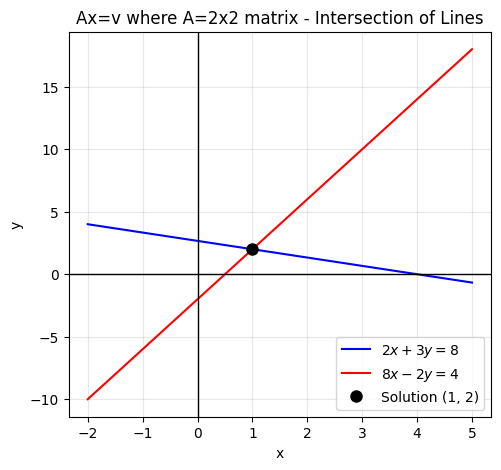

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Example 1
# Equation 1: 2x + 3y = 8
# Equation 2: 8x - 2y = 4
A = np.array([[2, 3],
              [8, -2]])
v = np.array([8, 4])

sol = np.linalg.solve(A, v)
x_sol, y_sol = sol

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Ax=v where A=2x2 matrix - Intersection of Lines")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)

# Define a range of x values for plotting lines
x_vals = np.linspace(-2, 5, 100)

# Rewrite Eq 1: 3y = 8 - 2x  =>  y = (8 - 2x) / 3
y_vals_1 = (v[0] - A[0,0]*x_vals) / A[0,1]

# Rewrite Eq 2: -2y = 4 - 8x =>  y = (4 - 8x) / -2
y_vals_2 = (v[1] - A[1,0]*x_vals) / A[1,1]

# Plot the lines
plt.plot(x_vals, y_vals_1, 'b-', label=r'$2x + 3y = 8$')
plt.plot(x_vals, y_vals_2, 'r-', label=r'$8x - 2y = 4$')

# Plot the solution point
plt.plot(x_sol, y_sol, 'ko', markersize=8, label=f'Solution ({x_sol:.0f}, {y_sol:.0f})')
plt.legend()
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)


We can visualize the act of this matrix acting on the vector (1,2) to give us (8,4) as a stretching, shear, and/or rotation:

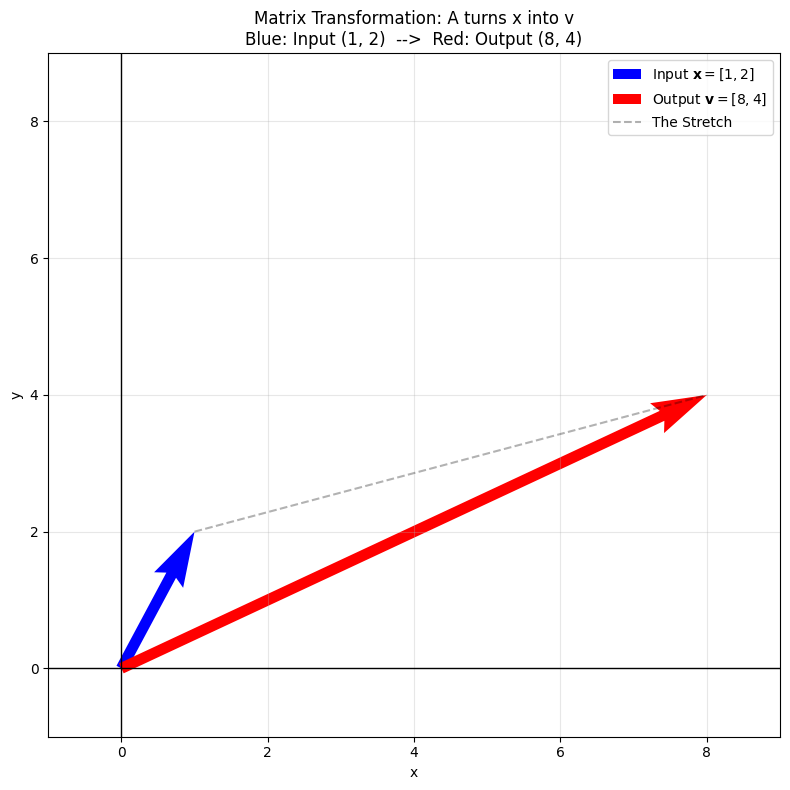

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Matrix A
A = np.array([[2, 3],
              [8, -2]])

# The Input Vector x (
x = np.array([1, 2])

# The Output Vector v (The target)
# We calculate it to prove A stretches x into v
v = A @ x

# Plot
plt.figure(figsize=(8, 8))
plt.title(f"Matrix Transformation: A turns x into v\nBlue: Input (1, 2)  -->  Red: Output (8, 4)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Origin
origin = np.array([0, 0])

# Plot Input Vector x (Blue)
plt.quiver(*origin, x[0], x[1], color='b', angles='xy', scale_units='xy', scale=1,
           width=0.015, label=r'Input $\mathbf{x} = [1, 2]$')

# Plot Output Vector v (Red)
plt.quiver(*origin, v[0], v[1], color='r', angles='xy', scale_units='xy', scale=1,
           width=0.015, label=r'Output $\mathbf{v} = [8, 4]$')

# Draw a dashed line connecting tip of x to tip of v to visualize the "movement"
plt.plot([x[0], v[0]], [x[1], v[1]], 'k--', alpha=0.3, label='The Stretch')

# Set limits to see both vectors clearly
plt.xlim(-1, 9)
plt.ylim(-1, 9)
plt.legend()

plt.tight_layout()
plt.show()

## Gaussian Elimination with Backsubstitution

We want to solve a system of linear equations represented by the matrix equation:

$$\mathbf{A} \vec{x} = \vec{v}$$

Where:
* $\mathbf{A}$ is a known $N \times N$ matrix of coefficients.
* $\vec{v}$ is a known vector of length $N$.
* $\vec{x}$ is the unknown vector of length $N$ that we wish to find.

While you likely have solved this type of equation in the past by inverting the matrix $\vec{x} = \textbf{A}^{-1} \vec{v}$, it turns out inverting a matrix is both computationally slow and numerically less precise (inverting the matrix requires more computational steps and therefore more rounding errors accumulate). The prefered computational method is Gaussian Elimination, which requires approximetly $\frac{2}{3} N^3$ floating point operations, where solving by inverting the matrix requires $2 N^3$ operations (3 times slower).

**Gaussian Elimination with Backsubstitution** has two steps:

1.  **Forward Elimination:** Transform matrix $\textbf{A}$ into an **Upper Triangular Matrix** (all elements below the diagonal are zero) by using row operations.
2.  **Backsubstitution:** Solve for the unknowns in $\vec{x}$ starting from the last equation and working backwards.




In [42]:
# Gaussian elimination with backsubstitution
# Modified book Example 6.1

from numpy import array,empty,zeros

# Define A and v which satisfy Ax=v where x is a vector with N elements

# NxN array

"""
# Example 1
A = array([[ 2,   3 ],
           [ 8,  -2 ]], float)
# 1D array with N elements
v = array([ 8,4],float)

"""

# Example 2 ( from the book):

A = array([[ 2,  1,  4,  1 ],
           [ 3,  4, -1, -1 ],
           [ 1, -4,  1,  5 ],
           [ 2, -2,  1,  3 ]], float)
v = array([ -4, 3, 9, 7 ],float)


# N equations and N unknowns
N = len(v)
print("N=",N)

print("-------------")
print("Before GE")
print("Matrix =")
print(A)
print("Vector =")
print(v)
print("-------------")

# Choose if you want to print a lot:
verbose = True

# Gaussian elimination

#  For each row of A
for m in range(N):


    if verbose:
      print("Considering matrix row",m," of ",N)


    # Find the diagonal element of that row
    div = A[m,m]

    if verbose:
      print(" Diagonal element = ",div)

    # Divide every column of row m by that diagonal (apply also to v)
    A[m,:] /= div
    v[m] /= div

    if verbose:
      print(" Matrix after dividing by diagonal element for row ",m,"= ")
      print(A)
      print(" Vector after dividing by diagonal element for row ",m,"= ")
      print(v)

    # For each row under row m, subtract a multiple of row m such that mth column becomes zero

    #  Consider row i, where i is greater than m
    if verbose:
      print( "Loop over ever row i, where i is greater than our current row ",m)
    for i in range(m+1,N):

      # Get the multiplier (the value of row i column m)
      mult = A[i,m]

      if verbose:
        print("  Row",i, "multiplier",mult, " (the value or row ",i, "column", m,")")
        print("  Use numpy to change multiple columns in this row simultaneously")
        print("     Row ",i," -",mult,"* Row",m)

      # For each column in row i, subtract mult times the value of that column entry in row m (apply also to v)
      A[i,:] -= mult*A[m,:]
      v[i] -= mult*v[m]

      if verbose:
        print(" Matrix after subtract mult times the value of that column entry in row m = ")
        print(A)
        print(" Vector after subtract mult times the value of that column entry in row m = ")
        print(v)


# Print array after gaussian substititution
print("-------------")
print("After GE")
print("Matrix =")
print(A)
print("Vector =")
print(v)
print("-------------")

# Backsubstitution
x = zeros(N,float)

print("Start Backsubstitution (find x given Ax=v)")
print("-------------")
#  Start with the last row and step backwards
if verbose:
  print("   We already know the last row x[-1] =",v[N-1])
  print("   Use this to work backwards and find each x value for each row")
  print("   x is currently blank:",x)
for m in range(N-1,-1,-1):

    # Get the v value
    x[m] = v[m]

    if verbose:
      print("     Row ",m," ---> Assign initial x[",m,"] = vector component =",v[m])

    # First time through this loop is not entered.
    # In following m loops, we subtract each column entry of that row from the v value
    #  starting with the element to the right of the diagonal element
    for i in range(m+1,N):
        if verbose:
          print("      x[",m,"] before change =",x[m])
          print("      x[",m,"] = ", x[m] ,"- A[",m,",",i,"] * x[",i,"]" )
          print("               = ", x[m], " - ", A[m,i],"*", x[i] )
          print("               = ", x[m]  -  A[m,i]* x[i] )
        x[m] -= A[m,i]*x[i]
        if verbose:
          print("      x[",m,"] after change =",x[m])


print("-------------")
print("\nfinal result:")
print(x)

N= 4
-------------
Before GE
Matrix =
[[ 2.  1.  4.  1.]
 [ 3.  4. -1. -1.]
 [ 1. -4.  1.  5.]
 [ 2. -2.  1.  3.]]
Vector =
[-4.  3.  9.  7.]
-------------
Considering matrix row 0  of  4
 Diagonal element =  2.0
 Matrix after dividing by diagonal element for row  0 = 
[[ 1.   0.5  2.   0.5]
 [ 3.   4.  -1.  -1. ]
 [ 1.  -4.   1.   5. ]
 [ 2.  -2.   1.   3. ]]
 Vector after dividing by diagonal element for row  0 = 
[-2.  3.  9.  7.]
Loop over ever row i, where i is greater than our current row  0
  Row 1 multiplier 3.0  (the value or row  1 column 0 )
  Use numpy to change multiple columns in this row simultaneously
     Row  1  - 3.0 * Row 0
 Matrix after subtract mult times the value of that column entry in row m = 
[[ 1.   0.5  2.   0.5]
 [ 0.   2.5 -7.  -2.5]
 [ 1.  -4.   1.   5. ]
 [ 2.  -2.   1.   3. ]]
 Vector after subtract mult times the value of that column entry in row m = 
[-2.  9.  9.  7.]
  Row 2 multiplier 1.0  (the value or row  2 column 0 )
  Use numpy to change multi

Repeat the code above but comment out example 2.

Note the "signed zeros" in example 2. When the computer divided zero by a negative number we got a negative zero. Note also that python interprets -0.0 == 0.0 to be `True`.

Note also: Gaussian Elimination (GE) results in an "upper triangular" matrix, aka "echelon" form.

One can manipulate the matrix further (Gauss-Jordon elimination) to produce "reduced row echelon form"
but this is typically not done computationally...it requires ~50% more computation time than the method above.


We also run into an issue when the upper left element of the matrix is a zero:

In [43]:
# Gaussian elimination with backsubstitution
# We encounter a problem when the matrix has upper left zero !

from numpy import array,empty

# Define A and v which satisfy Ax=v where x is a vector with N elements

# NOTE: MODIFIED MATRIX A W.R.T. PREVIOUS EXAMPLE

# NxN array
A = array([[ 0,   3 ],
           [ 8,  -2 ]], float)
# 1D array with N elements
v = array([ 8,4],float)


# For reference:
# Example from the book:

#A = array([[ 2,  1,  4,  1 ],
#           [ 3,  4, -1, -1 ],
#           [ 1, -4,  1,  5 ],
#           [ 2, -2,  1,  3 ]], float)
#v = array([ -4, 3, 9, 7 ],float)


# N equations and N unknowns
N = len(v)
print("N=",N)

print("Before GE")
print(A)

# Gaussian elimination

#  For each row of A
for m in range(N):

    # Find the diagonal element of that row
    div = A[m,m]

    # Divide every column of row m by that diagonal (apply also to v)
    A[m,:] /= div
    v[m] /= div

    # For each row under row m, subtract a multiple of row m such that mth column becomes zero

    #  Consider row i, where i is greater than m
    for i in range(m+1,N):
        # Get the multiplier (the value of row i column m)
        mult = A[i,m]
        # For each column in row i, subtract mult times the value of that column entry in row m (apply also to v)
        A[i,:] -= mult*A[m,:]
        v[i] -= mult*v[m]

# Print array after gaussian substititution
print("After GE")
print(A)

# Backsubstitution
x = empty(N,float)

#  Start with the last row and step backwards
for m in range(N-1,-1,-1):

    # Get the v value
    x[m] = v[m]

    # First time through this loop is not entered.
    # In following m loops, we subtract each column entry of that row from the v value
    #  starting with the element to the right of the diagonal element
    for i in range(m+1,N):
        x[m] -= A[m,i]*x[i]

print("\nfinal result:")
print(x)

N= 2
Before GE
[[ 0.  3.]
 [ 8. -2.]]
After GE
[[nan inf]
 [nan nan]]

final result:
[nan nan]


/tmp/ipython-input-2506849426.py:43: RuntimeWarning: divide by zero encountered in divide
  A[m,:] /= div
/tmp/ipython-input-2506849426.py:43: RuntimeWarning: invalid value encountered in divide
  A[m,:] /= div
/tmp/ipython-input-2506849426.py:44: RuntimeWarning: divide by zero encountered in scalar divide
  v[m] /= div
/tmp/ipython-input-2506849426.py:44: RuntimeWarning: invalid value encountered in scalar divide
  v[m] /= div


What do we do if the first element of our matrix is zero? This breaks GE.



### Pivotting

Pivotting is the standard method of dealing with solving equations where element 0,0 is =0. First we will swap two rows by hand. Then we will discuss partial pivotting.




In [44]:
# Gaussian elimination with backsubstitution
# Here we Pivot "by hand" - swap the rows of A and v

from numpy import array,empty

# Define A and v which satisfy Ax=v where x is a vector with N elements


# NOTE: SWAPPED ROWS W.R.T. PREVIOUS EXAMPLE

# NxN array
A = array([[ 8,   -2 ],
           [ 0,   3 ]], float)
# 1D array with N elements
v = array([ 4,8],float)

# N equations and N unknowns
N = len(v)
print("N=",N)

print("Before GE")
print(A)

# Gaussian elimination

#  For each row of A
for m in range(N):

    # Find the diagonal element of that row
    div = A[m,m]

    # Divide every column of row m by that diagonal (apply also to v)
    A[m,:] /= div
    v[m] /= div

    # For each row under row m, subtract a multiple of row m such that mth column becomes zero

    #  Consider row i, where i is greater than m
    for i in range(m+1,N):
        # Get the multiplier (the value of row i column m)
        mult = A[i,m]
        # For each column in row i, subtract mult times the value of that column entry in row m (apply also to v)
        A[i,:] -= mult*A[m,:]
        v[i] -= mult*v[m]

# Print array after gaussian substititution
print("After GE")
print(A)

# Backsubstitution
x = empty(N,float)

#  Start with the last row and step backwards
for m in range(N-1,-1,-1):

    # Get the v value
    x[m] = v[m]

    # First time through this loop is not entered.
    # In following m loops, we subtract each column entry of that row from the v value
    #  starting with the element to the right of the diagonal element
    for i in range(m+1,N):
        x[m] -= A[m,i]*x[i]

print("\nfinal result:")
print(x)

N= 2
Before GE
[[ 8. -2.]
 [ 0.  3.]]
After GE
[[ 1.   -0.25]
 [ 0.    1.  ]]

final result:
[1.16666667 2.66666667]


In this simple example swapping rows worked to avoid this problem.

This swapping, or "pivotting", has to be done carefully. It is easy to introduce new problems when fixing this one.

The standards technique is "partial pivotting". Standard GE involves subtracting some multiple of the diagonal element for each element of a row for each column. Partial pivotting involves;

* Before moving to a new row, consider swapping that row for a different one (re-arranging rows at each stage)
* If you are starting row m, choose (swap) the row with mth element furthest from zero (positive or negative).
  * Reasoning: If the Pivot is very small (example: $0.00001$), the Multiplier becomes very large when scaling other rows ($100,000$). Subtracting large numbers hurts computational precision. For this reason we choose the row with the largest pivot in the column.

In [45]:
# Gaussian elimination with backsubstitution and pivoting
# Modified book Example 6.1

from numpy import array,empty

# Define A and v which satisfy Ax=v where x is a vector with N elements

# NxN array
#A = array([[ 0,   3 ],
#           [ 8,  -2 ]], float)
# 1D array with N elements
#v = array([ 8,4],float)

A = array([[ 0,  2,  7  ],
           [ 7,  1,  3 ],
           [ 2,  -5, 1 ]], float)

v = array([ -4, 3, 9  ],float)

# N equations and N unknowns
N = len(v)
print("N=",N)

print("Before GE")
print(A)

# Gaussian elimination

#  For each row of A
for m in range(N):

    print("\nIteration - row ",m)

    print("Before pivot")
    print(A)

    # Find row with biggest pivot element

    #  save the row number which you which to swap. initialize with the current row
    pivot = m

    #  inititalize "largest" with the diagonal element of the current row.
    largest = A[m,m]

    # for each row after the one you are currently looking at
    for i in range(m+1,N):
        # find the row which has element in column m which is largest
        if abs(A[i,m])>largest:
            largest = abs(A[i,m])
            pivot = i

    # Swap rows
    for i in range(N):
        A[m,i], A[pivot,i] = A[pivot,i], A[m,i]
    v[m],v[pivot] = v[pivot],v[m]

    print("After pivot")
    print(A)

    # Find the diagonal element of that row
    div = A[m,m]

    # Divide every column of row m by that diagonal (apply also to v)
    A[m,:] /= div
    v[m] /= div

    # For each row under row m, subtract a multiple of row m such that mth column becomes zero

    #  Consider row i, where i is greater than m
    for i in range(m+1,N):
        # Get the multiplier (the value of row i column m)
        mult = A[i,m]
        # For each column in row i, subtract mult times the value of that column entry in row m (apply also to v)
        A[i,:] -= mult*A[m,:]
        v[i] -= mult*v[m]

# Print array after gaussian substititution
print("After GE")
print(A)

# Backsubstitution
x = empty(N,float)

#  Start with the last row and step backwards
for m in range(N-1,-1,-1):

    # Get the v value
    x[m] = v[m]

    # First time through this loop is not entered.
    # In following m loops, we subtract each column entry of that row from the v value
    #  starting with the element to the right of the diagonal element
    for i in range(m+1,N):
        x[m] -= A[m,i]*x[i]

print("\nfinal result:")
print(x)

N= 3
Before GE
[[ 0.  2.  7.]
 [ 7.  1.  3.]
 [ 2. -5.  1.]]

Iteration - row  0
Before pivot
[[ 0.  2.  7.]
 [ 7.  1.  3.]
 [ 2. -5.  1.]]
After pivot
[[ 7.  1.  3.]
 [ 0.  2.  7.]
 [ 2. -5.  1.]]

Iteration - row  1
Before pivot
[[ 1.          0.14285714  0.42857143]
 [ 0.          2.          7.        ]
 [ 0.         -5.28571429  0.14285714]]
After pivot
[[ 1.          0.14285714  0.42857143]
 [ 0.         -5.28571429  0.14285714]
 [ 0.          2.          7.        ]]

Iteration - row  2
Before pivot
[[ 1.          0.14285714  0.42857143]
 [-0.          1.         -0.02702703]
 [ 0.          0.          7.05405405]]
After pivot
[[ 1.          0.14285714  0.42857143]
 [-0.          1.         -0.02702703]
 [ 0.          0.          7.05405405]]
After GE
[[ 1.          0.14285714  0.42857143]
 [-0.          1.         -0.02702703]
 [ 0.          0.          1.        ]]

final result:
[ 0.70498084 -1.5440613  -0.1302682 ]


## Lower Upper (LU) Decomposition

In Gaussian Elimination, we modify both the matrix $\mathbf{A}$ and the vector $\vec{v}$ simultaneously.
But what if we want to solve $\mathbf{A}\vec{x} = \vec{v}$ for many different vectors $\vec{v}_1, \vec{v}_2, \vec{v}_3 \dots$ while $A$ stays the same?

Running full Gaussian Elimination for every single $\vec{v}$ is inefficient because the heavy lifting (manipulating $N^2$ elements of $\mathbf{A}$) is repeated every time.

**LU Decomposition** solves this by factoring the matrix $A$ once into two triangular matrices:
$$\mathbf{A} = \mathbf{L} \mathbf{U}$$
* **L (Lower):** A lower triangular matrix (zeros above the diagonal).
* **U (Upper):** An upper triangular matrix (zeros below the diagonal).

Once we have $\mathbf{L}$ and $\mathbf{U}$, we can solve for any new vector $\vec{v}$ very quickly using two backsubstitution steps.


### LU Decomposition Steps

#### Step 1 - Figure out L and U such that $A = LU$

We perform operations similar to Gaussian Elimination, but instead of throwing away the multipliers we used to eliminate rows, we store them in $L$.

The standard algorithm produces:
* **Upper Matrix ($U$):** Contains the coefficients after elimination (with 1s on the diagonal).
* **Lower Matrix ($L$):** Contains the "multipliers" used during elimination and the original pivot values.

$$
\mathbf{A} =
\begin{bmatrix}
L_{00} & 0 \\
L_{10} & L_{11}
\end{bmatrix}
\begin{bmatrix}
1 & U_{01} \\
0 & 1
\end{bmatrix}
$$


Once we have $\mathbf{A} = \mathbf{L}\mathbf{U}$, our system $\mathbf{A}\vec{x} = \vec{v}$ becomes:
$$\mathbf{L}(\mathbf{U}\vec{x}) = \vec{v}$$

We solve this in two steps by introducing an intermediate vector $\vec{y} = \mathbf{U}\vec{x}$:

#### Step 2: Forward Substitution (Find $\mathbf{y}$)
Solve $\mathbf{L}\vec{y} = \vec{v}$ for $\vec{y}$.
Since $\mathbf{L}$ is lower triangular, we can solve for $y_0$ immediately, then $y_1$, etc.
$$y_m = \frac{1}{\mathbf{L}_{mm}} \left( v_m - \sum_{i=0}^{m-1} \mathbf{L}_{mi} y_i \right)$$

#### Step 3: Backward Substitution (Find $\vec{x}$)
Solve $\mathbf{U}\vec{x} = \vec{y}$ for $\vec{x}$.
Since $\mathbf{U}$ is upper triangular, we solve backwards starting from the last row.
Because our $\mathbf{U}$ has 1s on the diagonal, the division step is skipped:
$$x_m = y_m - \sum_{i=m+1}^{N-1} \mathbf{U}_{mi} x_i$$

In [46]:
# LU Decomposition (Warning: no pivoting. Code will crash if first element is zero)
from numpy import zeros, empty, copy, array

verbose = True  # Set to False to suppress detailed print statements

# Example 1
#A = array([[ 6,  2,  7  ],
#           [ 7,  1,  3 ],
#           [ 2,  -5, 1 ]], float)

#v = array([ -4, 3, 9  ],float)

# Example 2
A = array([[ 2,  1,  4,  1 ],
           [ 3,  4, -1, -1 ],
           [ 1, -4,  1,  5 ],
           [ 2, -2,  1,  3 ]], float)

v = array([ -4, 3, 9, 7 ],float)

N = len(v)

# Save a copy of A for later reference
A_ref = A.copy()



# Helper funciton to print matrix equation in a clear way
def print_matrix_system(M, var_char, result_vec):
    """
    Prints [Matrix] [Vector] = [Result] in ASCII art style.
    M: The Matrix (L or U)
    var_char: The character for the variable vector ('y' or 'x')
    result_vec: The result vector (v or y)
    """
    # Find the middle row for placing 'x' and '=' signs
    mid_row = N // 2

    for r in range(N):
        # 1. Start the row string
        row_str = "| "

        # 2. Add Matrix Values
        for c in range(N):
            # Format matrix elements with width 6 and 2 decimal places
            row_str += f"{M[r,c]:6.2f} "

        row_str += "|"

        # 3. Add Variable Vector element (e.g., | y0 |)
        # We put a multiplication 'x' or dot on the middle row
        operator = " * " if r == mid_row else "   "
        row_str += f"{operator}| {var_char}{r} |"

        # 4. Add Result Vector element
        # We put an equals '=' on the middle row
        equals = " = " if r == mid_row else "   "
        row_str += f"{equals}| {result_vec[r]:6.2f} |"

        print(row_str)
    print("\n")

def LU_decomposition(matrix_in):
    L = zeros([N,N],float)
    U = copy(matrix_in)

    if verbose:
        print("=== START LU DECOMPOSITION ===")
        print(f"Initial Matrix A:\n{U}\n")

    for m in range(N):
        print(f"--- Processing Column {m} ---")

        # 1. EXTRACT TO L
        # We take a "snapshot" of the current column in U.
        # These values are copied directly into L.
        current_column_values = U[m:N, m]
        L[m:N,m] = U[m:N,m]

        print(f"  > Extracted column {m} to L. These are the current values in U:")
        print(f"    Values copied: {current_column_values}")
        print(f"    * L[{m},{m}] = {L[m,m]} is the PIVOT for this step.")
        if N > m+1:
            print(f"    * L[{m+1}:, {m}] = {L[m+1:,m]} are the values we must eliminate.")

        # 2. NORMALIZE U
        div = U[m,m]
        U[m,:] /= div
        print(f"  > Normalized Row {m} of U by dividing by pivot {div:.2f}")
        print(f"    (The diagonal U[{m},{m}] is now 1.0)")

        # 3. ELIMINATE ROWS BELOW
        print("  > Elimination Loop:")
        for i in range(m+1,N):
            mult = U[i,m]
            # Explanation: Since U[m,m] is 1, the multiplier needed to kill U[i,m] is just U[i,m] itself.
            print(f"    - Row {i}: Value to eliminate is {mult:.2f}.")
            print(f"      Operation: Row_{i} = Row_{i} - ({mult:.2f} * Row_{m})")

            U[i,:] -= mult*U[m,:]

        if verbose:
            print(f"\n  Resulting U after step {m}:\n{U}\n")

    return L,U

# --- MAIN EXECUTION ---

# Print Original problem
print("Goal: Solve A*x = v:")
print_matrix_system(A, 'x', v)
print("="*30 + "\n")

# Step 1 - Perform Decomposition
print("Step 1: Find L and U such that A=LU (Decomposition)")

L, U = LU_decomposition(A)

print("=== FINAL MATRICES AFTER DECOMPOSITION ===")
print("Lower Matrix L (contains original pivots on diagonal):")
print(L)
print("\nUpper Matrix U (contains 1s on diagonal):")
print(U)

print("\nCompare these to the orignal A:")
print(A)

print("\nCheck A = LU (Perform L @ U )")
print(L @ U)

print("\n" + "="*30 + "\n")


# Step 2 - Forward Substitution
# Solve L * y = v for intermediate vector y
print("Step 2: Solve Ly = v for y (Forward Substitution)")
print_matrix_system(L, 'y', v)

y = empty(N,float)

for m in range(N):
    # Start with the corresponding v value
    y[m] = v[m]

    # Subtract the known y values from the "left" of the current column
    for i in range(m):
        y[m] -= L[m,i]*y[i]

    # Divide by the diagonal of L (because L diagonal contains pivots, not 1s)
    y[m] /= L[m,m]

    if verbose:
        print(f"  Row {m}: Found y[{m}] = {y[m]:.4f}")

print(f"\nIntermediate vector y: {y}")
print("\n" + "="*30 + "\n")


# Step 3 - Backward Substitution
# Solve U * x = y for final vector x
print("Step 3: Solve Ux = y for x (Backward Substitution)")
print_matrix_system(U, 'x', y)
x = empty(N,float)

# Start from the bottom row (N-1) and move up to 0
for m in range(N-1,-1,-1):
    # Initialize with the value from y
    x[m] = y[m]

    # Subtract the known x values from the "right" of the diagonal
    for i in range(m+1,N):
        x[m] -= U[m,i]*x[i]

    # Note: No division needed here because U diagonal elements are all 1.0!

    if verbose:
        print(f"  Row {m}: Found x[{m}] = {x[m]:.4f}")

print("\n" + "="*30)
print("FINAL RESULT x:")
print(x)

Goal: Solve A*x = v:
|   2.00   1.00   4.00   1.00 |   | x0 |   |  -4.00 |
|   3.00   4.00  -1.00  -1.00 |   | x1 |   |   3.00 |
|   1.00  -4.00   1.00   5.00 | * | x2 | = |   9.00 |
|   2.00  -2.00   1.00   3.00 |   | x3 |   |   7.00 |



Step 1: Find L and U such that A=LU (Decomposition)
=== START LU DECOMPOSITION ===
Initial Matrix A:
[[ 2.  1.  4.  1.]
 [ 3.  4. -1. -1.]
 [ 1. -4.  1.  5.]
 [ 2. -2.  1.  3.]]

--- Processing Column 0 ---
  > Extracted column 0 to L. These are the current values in U:
    Values copied: [2. 3. 1. 2.]
    * L[0,0] = 2.0 is the PIVOT for this step.
    * L[1:, 0] = [3. 1. 2.] are the values we must eliminate.
  > Normalized Row 0 of U by dividing by pivot 2.00
    (The diagonal U[0,0] is now 1.0)
  > Elimination Loop:
    - Row 1: Value to eliminate is 3.00.
      Operation: Row_1 = Row_1 - (3.00 * Row_0)
    - Row 2: Value to eliminate is 1.00.
      Operation: Row_2 = Row_2 - (1.00 * Row_0)
    - Row 3: Value to eliminate is 2.00.
      Operation: 

## Numpy and SciPy Tools for Solving Systems of Linear Equations

Numpy and SciPy have many tools which can help us with linear algebra. For our example above, we can use `np.linalg.solve` to solve a system of linear equations. Simply give it A and v and it will find x such that Ax=v:

In [47]:
# Solve with Numpy
import numpy as np


A = np.array([[ 2,  1,  4,  1 ],
           [ 3,  4, -1, -1 ],
           [ 1, -4,  1,  5 ],
           [ 2, -2,  1,  3 ]], float)
v = np.array([ -4, 3, 9, 7 ],float)

x= np.linalg.solve(A,v)
print(x)

[ 2. -1. -2.  1.]


In [48]:
# Solve with scipy
import numpy as np
from scipy import linalg

A = np.array([[ 2,  1,  4,  1 ],
           [ 3,  4, -1, -1 ],
           [ 1, -4,  1,  5 ],
           [ 2, -2,  1,  3 ]], float)

v = np.array([ -4, 3, 9, 7 ],float)

# scipy.linalg.solve is functionally identical to numpy.linalg.solve
# for general matrices, but often slightly faster and offers more options.
x = linalg.solve(A, v)

print(x)

[ 2. -1. -2.  1.]


Under the hood, numpy.linalg and scipy.linalg are both wrappers around LAPACK (Linear Algebra PACKage), a standard software library for numerical linear algebra written in Fortran. For solving systems of linear equations it defaults to using LU Decomposition with partial pivoting. They both also use BLAS (Basic Linear Algebra Subprograms) for simple things like matrix multiplication.

Just for fun, lets compare numpy `np.linalg.solve` to the alternative method of inverting the matrix with `np.linalg.inv(A)` to solve a large system of equations:

In [49]:
import numpy as np
import time

# Create a large random system
N = 2000
print(f"Generating a {N}x{N} system of equations...")
A = np.random.rand(N, N)
v = np.random.rand(N)

# METHOD A: GAUSSIAN ELIMINATION (solve)
start_time = time.time()
x_solve = np.linalg.solve(A, v)
end_time = time.time()
time_solve = end_time - start_time

print(f"Method 1: np.linalg.solve(A, v)")
print(f"Time: {time_solve:.4f} seconds")
print("-" * 30)

# METHOD B: INVERSION (inv)
start_time = time.time()
A_inv = np.linalg.inv(A)
x_inv = A_inv @ v
end_time = time.time()
time_inv = end_time - start_time

print(f"Method 2: np.linalg.inv(A) @ v")
print(f"Time: {time_inv:.4f} seconds")
print("-" * 30)

# RESULTS
ratio = time_inv / time_solve
print(f"Speedup Factor: 'solve' was {ratio:.2f}x faster than 'inv'")

# Check accuracy
# Even though inv is slower, does it give the same answer?
diff = np.linalg.norm(x_solve - x_inv)
print(f"\nDifference in answers: {diff:.2e}")

Generating a 2000x2000 system of equations...
Method 1: np.linalg.solve(A, v)
Time: 0.3216 seconds
------------------------------
Method 2: np.linalg.inv(A) @ v
Time: 0.9735 seconds
------------------------------
Speedup Factor: 'solve' was 3.03x faster than 'inv'

Difference in answers: 5.96e-10


## Determinant with NumPy or SciPy

In [50]:
import numpy as np
from scipy import linalg

# Example
A = np.array([[1, 2],
              [3, 4]])

# Calculate Determinant (Method A: NumPy)
det_np = np.linalg.det(A)
print(f"NumPy Determinant: {det_np}")
# Expected: (1*4) - (2*3) = -2.0

# Calculate Determinant (Method B: SciPy)
# SciPy is often faster for large matrices.
det_sp = linalg.det(A)
print(f"SciPy Determinant: {det_sp}")

# THE "SLOGDET"
# In physics, determinants of large matrices (N > 100) often explode to infinity
# or vanish to zero because of floating point math.
# Example: det(A) might be 1.0e+300.

# 'slogdet' calculates the Sign and the (Natural) Log of the determinant.
# This keeps the number manageable (e.g., 300 instead of 1e300).
sign, logdet = np.linalg.slogdet(A)

print(f"Log-Determinant:   {logdet:.4f}")
print(f"Sign:              {sign}")
print(f"Reconstructed:     {sign * np.exp(logdet):.2f}")

NumPy Determinant: -2.0000000000000004
SciPy Determinant: -2.0
Log-Determinant:   0.6931
Sign:              -1.0
Reconstructed:     -2.00


## Eigenvalues and Eigenvectors

In linear algebra, a matrix $A$ acts as a linear transformation (it stretches, rotates, or shears vectors).
Most vectors change direction when transformed by $A$. However, there are special vectors that **do not change direction**; they are merely scaled (stretched or shrunk) by the matrix.

These are called **Eigenvectors**. The factor by which they are scaled is called the **Eigenvalue**.

$$\mathbf{A} \vec{v} = \lambda \vec{v}$$

* $\mathbf{A}$ is a square matrix ($N \times N$).
* $\vec{v}$ is the **Eigenvector** (a non-zero column vector).
* $\lambda$ is the **Eigenvalue** (a scalar number, which can be complex).

To find these computationally, we rewrite the equation as $(\mathbf{A} - \lambda \mathbf{I})\vec{v} = 0$. For a non-zero solution $\vec{v}$ to exist, the determinant must be zero:
$$\det(\mathbf{A} - \lambda \mathbf{I}) = 0$$

### Eigen Value Equations in NumPy and SciPY

In the following code, we will solve eigenvalue problems using both standard libraries.

* `eig(A)`: General solver. Returns eigenvalues and eigenvectors for any square matrix.
* `eigh(A)`: **Hermitian/Symmetric** solver. Use this when your matrix is symmetric ($A^T = A$) or Hermitian ($A^\dagger = A$, [the entry in row $i$, column $j$ must be the complex conjugate of the entry in row $j$, column $i$]). It is faster and guarantees real eigenvalues (crucial for Physics).


### Physics use:
* **Quantum Mechanics:** $H \psi = E \psi$. The Hamiltonian operator $H$ is the matrix, the wavefunction $\psi$ is the eigenvector, and the energy $E$ is the eigenvalue.
* **Rotation:** The axis of rotation is an eigenvector with eigenvalue $\lambda=1$ (it doesn't move).
* **Vibrations:** The "normal modes" of a system (like a bridge or a molecule) are the eigenvectors of the stiffness matrix.
* **Principal Axes:** 3D rotating objects have unique axes where L and omega are aligned.

In [51]:
import numpy as np
from scipy import linalg

# Simple 2x2 matrix
A = np.array([[0, 1],
              [-2, -3]])

print("Original Matrix A:")
print(A)
print("-" * 30)

# SOLVING WITH NUMPY
# np.linalg.eig returns a tuple: (eigenvalues, eigenvectors)
evals_np, evecs_np = np.linalg.eig(A)

print("=== NUMPY RESULTS ===")
print(f"Eigenvalues: {evals_np}")
print("Eigenvectors (columns):\n", evecs_np)
print("-" * 30)


# SOLVING WITH SCIPY
# scipy.linalg.eig is similar, but can handle more complex cases
# (like generalized eigenvalue problems Av = lambda Bv)
evals_sp, evecs_sp = linalg.eig(A)

print("=== SCIPY RESULTS ===")
print(f"Eigenvalues: {evals_sp}")
print("Eigenvectors (columns):\n", evecs_sp)
print("-" * 30)


# VERIFICATION (A*v = lambda*v)
print("=== VERIFICATION ===")

# Important Note: The eigenvectors are the COLUMNS of the result matrix.
# We extract the first eigenvector (column 0) and first eigenvalue
lambda_1 = evals_np[0]
v_1 = evecs_np[:, 0]

# Calculate LHS: A * v
LHS = A @ v_1

# Calculate RHS: lambda * v
RHS = lambda_1 * v_1

print(f"LHS (A @ v):      {LHS}")
print(f"RHS (lambda * v): {RHS}")

is_match = np.allclose(LHS, RHS)
print(f"Do they match?    {is_match}")


# Repeat for SPECIAL CASE: SYMMETRIC / HERMITIAN MATRICES ---
# In physics, our matrices are often symmetric (real) or Hermitian (complex).
# For these, ALWAYS use 'eigh' (h for Hermitian). It is faster and numerically more stable.

print("-" * 30)
print("=== SYMMETRIC EXAMPLE (eigh) ===")
H = np.array([[2, 1],
              [1, 2]]) # Symmetric Matrix

# Note 'eigh' instead of 'eig'
evals_h, evecs_h = np.linalg.eigh(H)

print("Hamiltonian (Symmetric) H:\n", H)
print("Real Eigenvalues:", evals_h)

Original Matrix A:
[[ 0  1]
 [-2 -3]]
------------------------------
=== NUMPY RESULTS ===
Eigenvalues: [-1. -2.]
Eigenvectors (columns):
 [[ 0.70710678 -0.4472136 ]
 [-0.70710678  0.89442719]]
------------------------------
=== SCIPY RESULTS ===
Eigenvalues: [-1.+0.j -2.+0.j]
Eigenvectors (columns):
 [[ 0.70710678 -0.4472136 ]
 [-0.70710678  0.89442719]]
------------------------------
=== VERIFICATION ===
LHS (A @ v):      [-0.70710678  0.70710678]
RHS (lambda * v): [-0.70710678  0.70710678]
Do they match?    True
------------------------------
=== SYMMETRIC EXAMPLE (eigh) ===
Hamiltonian (Symmetric) H:
 [[2 1]
 [1 2]]
Real Eigenvalues: [1. 3.]


### Principal Moments of Inertia

In Classical Mechanics, the relationship between Angular Momentum ($\vec{L}$) and Angular Velocity ($\vec{\omega}$) is not simple multiplication. It is a matrix equation:

$$\vec{L} = \mathbf{I} \vec{\omega}$$

Where $\mathbf{I}$ is the **Inertia Tensor**, a $3 \times 3$ symmetric matrix.
$$
\mathbf{I} =
\begin{bmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz}
\end{bmatrix}
$$

Usually, this matrix contains off-diagonal terms ($I_{xy}$, etc.), which means that rotating an object purely around the x-axis ($ \vec{\omega} = [\omega, 0, 0]$) creates Angular Momentum in the y and z directions (wobble).

We want to find a rotated coordinate system (body-fixed frame) where the matrix becomes **diagonal**. In this special frame, the object rotates cleanly without wobbling.

* The **Eigenvalues** of $\mathbf{I}$ are the **Principal Moments of Inertia** ($I_1, I_2, I_3$).
* The **Eigenvectors** are the **Principal Axes** (the directions of these new $x', y', z'$ axes).

Because the Inertia Tensor is real and symmetric, we always use `numpy.linalg.eigh`.

In [52]:
import numpy as np

# Define an object formed out of 4 masses at specific (x, y, z) coordinates.
masses = np.array([1.0, 2.0, 1.0, 3.0]) # kg

# Positions [x, y, z] for each mass in meters
positions = np.array([
    [ 2.0,  0.0,  0.0], # Mass 0 on x-axis
    [ 0.0,  3.0,  0.0], # Mass 1 on y-axis
    [ 0.0,  0.0,  1.0], # Mass 2 on z-axis
    [ 1.0,  1.0,  1.0]  # Mass 3 floating in space
])

# Intertia Tensor has equations for diagonals and off diagonals
# I_xx = sum( m * (y^2 + z^2) )
# I_xy = - sum( m * x * y )

I = np.zeros((3,3))

print("Calculating Inertia Tensor...")

for m, r in zip(masses, positions): # Loop over both masses and positions simultaneously (zip creates a sequence of tuples (mass, r-vector))
    x, y, z = r # unpack the r array to get coordinates

    # Diagonal elements
    I[0,0] += m * (y**2 + z**2)
    I[1,1] += m * (x**2 + z**2)
    I[2,2] += m * (x**2 + y**2)

    # Off-diagonal elements (Symmetric)
    I[0,1] -= m * x * y
    I[1,0] = I[0,1] # Symmetry

    I[0,2] -= m * x * z
    I[2,0] = I[0,2]

    I[1,2] -= m * y * z
    I[2,1] = I[1,2]

print("Inertia Tensor I (Standard Basis):")
print(I)
print("-" * 30)


# Find principle moments and princilpe axes (eigen values and eigen vectors)
# Since I is symmetric, we use 'np.linalg.eigh' to find eigenvalues
principal_moments, principal_axes = np.linalg.eigh(I)

print("Principal Moments of Inertia (Eigenvalues):")
for i, val in enumerate(principal_moments):
    print(f"  I_{i+1} = {val:.4f} kg·m²")

print("\nPrincipal Axes (Eigenvectors - Columns):")
# Each column is a unit vector pointing along a principal axis
print(principal_axes)

# Check
# Principal axes of a symmetric matrix must be orthogonal (dot product = 0)
v1 = principal_axes[:, 0]
v2 = principal_axes[:, 1]
dot_prod = np.dot(v1, v2)

print("\nCheck: Dot product of Axis 1 and Axis 2:")
print(f"  {dot_prod:.4e} (Should be close to zero)")

# Write down the moment of inertia tensor using the principal axes as the basis
# Theory: To rotate a tensor/matrix into a new basis, we perform a Similarity Transformation.
# I_body = R_transpose * I_space * R
# Since R is orthogonal, R_transpose is the same as R_inverse.
R = principal_axes
I_body = R.T @ I @ R

print("\n Transformed Inertia Tensor")
print(np.round(I_body, 4)) # Use np.round to hide floating point errors (like 1e-15)

print("\nAnalysis:")
print("Notice that this matrix is diagonal and the values on the diagonal match the Principal Moments exactly.")

Calculating Inertia Tensor...
Inertia Tensor I (Standard Basis):
[[25. -3. -3.]
 [-3. 11. -3.]
 [-3. -3. 28.]]
------------------------------
Principal Moments of Inertia (Eigenvalues):
  I_1 = 9.6862 kg·m²
  I_2 = 24.4018 kg·m²
  I_3 = 29.9121 kg·m²

Principal Axes (Eigenvectors - Columns):
[[-0.22495239  0.84005419 -0.49366524]
 [-0.95500554 -0.29059496 -0.05932105]
 [-0.19328953  0.45810863  0.86762644]]

Check: Dot product of Axis 1 and Axis 2:
  -1.3878e-17 (Should be close to zero)

 Transformed Inertia Tensor
[[ 9.6862 -0.     -0.    ]
 [-0.     24.4018  0.    ]
 [-0.      0.     29.9121]]

Analysis:
Notice that this matrix is diagonal and the values on the diagonal match the Principal Moments exactly.


# Matrix Conditioning and Numerical Stability

In computational physics we deal with:
* **Measurement Error:** Experimental data has uncertainties.
* **Floating Point Error:** Computers round off numbers.

A system of linear equations ($A\mathbf{x} = \mathbf{v}$) is considered **Ill-Conditioned** if a tiny error in $\mathbf{v}$ results in large error in $\mathbf{x}$. The matrix amplifies the noise. If visualizing the system of linear equations as an intersection, a well contitioned system intersects with a sharp angle so a small wiggle in one line does not effect the intersection point very much. An ill-conditioned system has lines that are almost parallel so they intersect at a very shallow angle. If you wiggle one line just a tiny bit, the intersection point slides far away.

We measure this sensitivity using the **Condition Number**, $\kappa(A)$, using `np.linalg.cond(A)`.

* $\kappa \approx 1$: **Perfect.** Errors are not amplified. (e.g., Identity Matrix).
* $\kappa \gg 1$: **Bad.** The system is sensitive to noise.



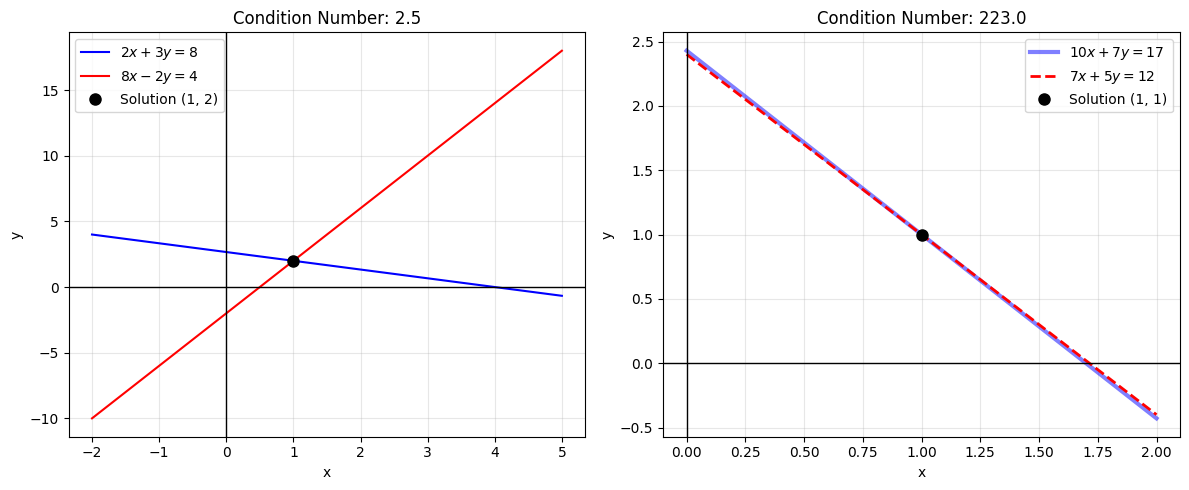

In [53]:
# Visualize Ill-conditioned matrices

import numpy as np
import matplotlib.pyplot as plt

# Notebook Example 1 ---
# Equation 1: 2x + 3y = 8
# Equation 2: 8x - 2y = 4
A = np.array([[2, 3],
              [8, -2]])
v = np.array([8, 4])

# Solve it (we know x=1, y=2)
sol = np.linalg.solve(A, v)
x_sol, y_sol = sol

cond_num = np.linalg.cond(A)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title(f"Condition Number: {cond_num:.1f}")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)

# Define a range of x values for plotting lines
x_vals = np.linspace(-2, 5, 100)

# Rewrite Eq 1: 3y = 8 - 2x  =>  y = (8 - 2x) / 3
y_vals_1 = (v[0] - A[0,0]*x_vals) / A[0,1]

# Rewrite Eq 2: -2y = 4 - 8x =>  y = (4 - 8x) / -2
y_vals_2 = (v[1] - A[1,0]*x_vals) / A[1,1]

# Plot the lines
plt.plot(x_vals, y_vals_1, 'b-', label=r'$2x + 3y = 8$')
plt.plot(x_vals, y_vals_2, 'r-', label=r'$8x - 2y = 4$')

# Plot the solution point
plt.plot(x_sol, y_sol, 'ko', markersize=8, label=f'Solution ({x_sol:.0f}, {y_sol:.0f})')
plt.legend()
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)


# ILL-CONDITIONED EXAMPLE
plt.subplot(1, 2, 2)

# Matrix A (Wilson Matrix)
A = np.array([[10, 7],
              [7, 5]])

# Vector v (Target)
# We choose v so the solution is exactly x=1, y=1
v = np.array([17, 12])

# Solve it
sol = np.linalg.solve(A, v)
x_sol, y_sol = sol

# Calculate Condition Number for display
cond_num = np.linalg.cond(A)

plt.title(f"Condition Number: {cond_num:.1f}")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)

# Define a range of x values centered around the solution (1,1)
x_vals = np.linspace(0, 2, 100)

# Eq 1: 10x + 7y = 17  =>  y = (17 - 10x) / 7
y_vals_1 = (v[0] - A[0,0]*x_vals) / A[0,1]

# Eq 2: 7x + 5y = 12   =>  y = (12 - 7x) / 5
y_vals_2 = (v[1] - A[1,0]*x_vals) / A[1,1]

# Plot the lines
plt.plot(x_vals, y_vals_1, 'b-', linewidth=3, alpha=0.5, label=r'$10x + 7y = 17$')
plt.plot(x_vals, y_vals_2, 'r--', linewidth=2, label=r'$7x + 5y = 12$')

# Plot the solution point
plt.plot(x_sol, y_sol, 'ko', markersize=8, label=f'Solution ({x_sol:.0f}, {y_sol:.0f})')
plt.legend()
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()



In [54]:
# Demonstrate that 0.1% noise leads to 2.5% error

import numpy as np

# SETUP AN ILL-CONDITIONED MATRIX
# This looks like a normal matrix, but the rows are almost linear combinations.
# (10/7 is approx 1.428, 7/5 is 1.400). They are "almost" parallel.
A = np.array([[10, 7],
              [ 7, 5]])

# SOLVE FOR A PERFECT INPUT
# Let's say the "True" vector v is [17, 12]
v_exact = np.array([17, 12])
x_exact = np.linalg.solve(A, v_exact)

print("=== EXACT SOLUTION ===")
print(f"Input v:  {v_exact}")
print(f"Result x: {x_exact}")
print("-" * 30)

# INTRODUCE TINY NOISE
# We change the input vector v by a tiny amount (0.01)
# This represents a measurement error of less than 0.1%
v_noisy = np.array([17.01, 12.01])

x_noisy = np.linalg.solve(A, v_noisy)

print("=== NOISY SOLUTION (Input changed by ~0.06%) ===")
print(f"Input v:  {v_noisy}")
print(f"Result x: {x_noisy}")
print("-" * 30)

# ANALYZE THE ERROR
# How much did the input change?
input_error = np.linalg.norm(v_noisy - v_exact) / np.linalg.norm(v_exact)

# How much did the result change?
output_error = np.linalg.norm(x_noisy - x_exact) / np.linalg.norm(x_exact)

print(f"Input Error (Relative):  {input_error:.5%}")
print(f"Output Error (Relative): {output_error:.5%}  <-- ERROR AMPLIFICATION")

# CALCULATE CONDITION NUMBER
# We use np.linalg.cond to measure this sensitivity mathematically
k = np.linalg.cond(A)

print("-" * 30)
print(f"Condition Number k(A): {k:.2f}")
print(f"Interpretation: This matrix multiplies input errors by approx {k:.0f}.")

=== EXACT SOLUTION ===
Input v:  [17 12]
Result x: [1. 1.]
------------------------------
=== NOISY SOLUTION (Input changed by ~0.06%) ===
Input v:  [17.01 12.01]
Result x: [0.98 1.03]
------------------------------
Input Error (Relative):  0.06796%
Output Error (Relative): 2.54951%  <-- ERROR AMPLIFICATION
------------------------------
Condition Number k(A): 223.00
Interpretation: This matrix multiplies input errors by approx 223.
